# Task 6: Filtering and Noise Removal
**Data Science in Cybersecurity – Practical Assignment**

This notebook removes duplicate records and filters out logically invalid or irrelevant entries from the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load output from Task 5
df = pd.read_csv('cybersecurity_task5.csv')
print(f'Dataset loaded  |  shape: {df.shape}')
df.head()

Dataset loaded  |  shape: (437, 17)


,flow_id,src_ip,src_port,dst_ip,dst_port,protocol,timestamp,flow_duration,tot_fwd_pkts,tot_bwd_pkts,pkt_size_avg,fwd_iat_mean,bwd_iat_mean,flow_bytes/s,flow_pkts/s,flag,label
0,flow_0000,7.140.125.58,99999,171.84.26.102,22,TCP,2024-01-03 10:47:07,NaN,212.0,140.0,527.750,2154.51,2757.13,819791.08,103.97,ACK,PORTSCAN
1,flow_0001,27.44.216.9,51191,161.156.119.110,8080,TCP,2024-01-19 14:55:33,NaN,-5.0,NaN,374.600,3870.88,1352.54,424592.44,708.53,SYN,BENIGN
2,flow_0003,130.13.101.184,99999,55.244.39.34,22,HTTP,2024-01-20 00:36:58,-999.0,NaN,264.0,1463.450,374.99,3251.68,740429.12,518.97,FIN,DDOS
3,flow_0004,140.214.112.115,51228,152.115.227.3,21,UDP,01-29-2024 22:31:54,9999999.0,NaN,452.0,1213.280,3138.95,1517.09,221694.04,382.59,FIN,BENIGN
4,flow_0005,208.3.81.179,16796,3.175.61.253,8080,TCP,01-22-2024 15:26:12,44392.0,300.0,NaN,2356.565,4023.63,4857.33,767843.93,590.34,SYN,BRUTE FORCE


## 6.1 – Remove Duplicate Records

In [2]:
# Count duplicates before removal
n_duplicates = df.duplicated().sum()
print(f'Exact duplicate rows: {n_duplicates}')

# Drop exact duplicates
df_clean = df.drop_duplicates()
print(f'Shape after removing duplicates: {df_clean.shape}')

Exact duplicate rows: 15
Shape after removing duplicates: (422, 17)


In [3]:
# Also check for duplicate Flow IDs (logical duplicates)
dup_flow_ids = df_clean.duplicated(subset=['flow_id'], keep=False)
print(f'Rows with duplicate Flow IDs: {dup_flow_ids.sum()}')

if dup_flow_ids.sum() > 0:
    print(df_clean[dup_flow_ids][['flow_id']].head(10))
    # Keep first occurrence of each flow_id
    df_clean = df_clean.drop_duplicates(subset=['flow_id'], keep='first')
    print(f'Shape after deduplicating Flow IDs: {df_clean.shape}')

Rows with duplicate Flow IDs: 0


## 6.2 – Filter Logically Invalid Records

We define "logically invalid" as:
1. **Negative numerical values** in fields that must be non-negative (durations, packet counts, sizes)
2. **Invalid port numbers** outside [0, 65535] (may remain if Task 4 was skipped)
3. **Zero total packets** – a flow with 0 forward AND 0 backward packets cannot exist
4. **Negative flow duration** – physically impossible

In [4]:
df_filtered = df_clean.copy()
removed_log = []

# ── Rule 1: Negative flow_duration ───────────────────────────────────────
if 'flow_duration' in df_filtered.columns:
    mask = df_filtered['flow_duration'] < 0
    removed_log.append(('negative flow_duration', mask.sum()))
    df_filtered = df_filtered[~mask]

# ── Rule 2: Negative packet counts ───────────────────────────────────────
for col in ['tot_fwd_pkts', 'tot_bwd_pkts']:
    if col in df_filtered.columns:
        mask = df_filtered[col] < 0
        removed_log.append((f'negative {col}', mask.sum()))
        df_filtered = df_filtered[~mask]

# ── Rule 3: Negative packet size ─────────────────────────────────────────
if 'pkt_size_avg' in df_filtered.columns:
    mask = df_filtered['pkt_size_avg'] < 0
    removed_log.append(('negative pkt_size_avg', mask.sum()))
    df_filtered = df_filtered[~mask]

# ── Rule 4: Zero total packets (both forward and backward are 0) ──────────
if 'tot_fwd_pkts' in df_filtered.columns and 'tot_bwd_pkts' in df_filtered.columns:
    mask = (df_filtered['tot_fwd_pkts'] == 0) & (df_filtered['tot_bwd_pkts'] == 0)
    removed_log.append(('zero total packets', mask.sum()))
    df_filtered = df_filtered[~mask]

# ── Rule 5: Invalid port range ────────────────────────────────────────────
for port_col in ['src_port', 'dst_port']:
    if port_col in df_filtered.columns:
        mask = (df_filtered[port_col] < 0) | (df_filtered[port_col] > 65535)
        removed_log.append((f'invalid {port_col}', mask.sum()))
        df_filtered = df_filtered[~mask]

print('Filtering Summary:')
for reason, count in removed_log:
    print(f'  Removed {count:>4} row(s) – {reason}')
print(f'\nShape after filtering: {df_filtered.shape}')

Filtering Summary:
  Removed  106 row(s) – negative flow_duration
  Removed  114 row(s) – negative tot_fwd_pkts
  Removed    0 row(s) – negative tot_bwd_pkts
  Removed    3 row(s) – negative pkt_size_avg
  Removed    0 row(s) – zero total packets
  Removed  146 row(s) – invalid src_port
  Removed    0 row(s) – invalid dst_port

Shape after filtering: (53, 17)


## 6.3 – Remove Constant or Near-Zero Variance Features (Noise)

Columns with zero variance carry no information and can be dropped.

In [5]:
numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns
variance = df_filtered[numeric_cols].var()
zero_var_cols = variance[variance == 0].index.tolist()

print(f'Zero-variance columns: {zero_var_cols}')

if zero_var_cols:
    df_filtered.drop(columns=zero_var_cols, inplace=True)
    print(f'Dropped {len(zero_var_cols)} zero-variance column(s).')
else:
    print('No zero-variance columns found.')

Zero-variance columns: []
No zero-variance columns found.


## 6.4 – Summary of Removed Records

=== Noise Removal Summary ===
  Original records :    437
  Records removed  :    384  (87.87%)
  Records retained :     53


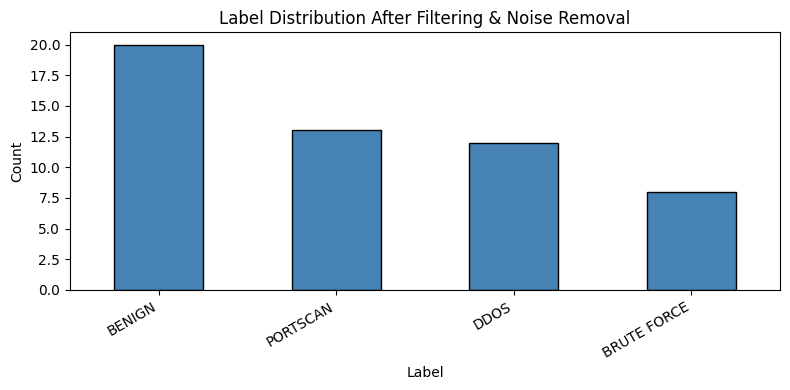

In [6]:
total_removed = len(df) - len(df_filtered)
pct_removed   = round(total_removed / len(df) * 100, 2)

print('=== Noise Removal Summary ===')
print(f'  Original records : {len(df):>6}')
print(f'  Records removed  : {total_removed:>6}  ({pct_removed}%)')
print(f'  Records retained : {len(df_filtered):>6}')

# Bar chart of label distribution after filtering
fig, ax = plt.subplots(figsize=(8, 4))
df_filtered['label'].value_counts().plot(kind='bar', ax=ax,
                                          color='steelblue', edgecolor='black')
ax.set_title('Label Distribution After Filtering & Noise Removal')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task6_label_distribution_filtered.png', dpi=150)
plt.show()

## 6.5 – Save for Next Task

In [7]:
df_filtered.to_csv('cybersecurity_task6.csv', index=False)
print(f'Filtered dataset saved to cybersecurity_task6.csv  |  shape: {df_filtered.shape}')

Filtered dataset saved to cybersecurity_task6.csv  |  shape: (53, 17)
